# TASK 2

FEATURE ENGINEERING, MODEL OPTIMIZATION & PERFORMANCE COMPARISON

# 1. Aim

To develop and compare multiple Machine Learning regression models for House Price Prediction using the California Housing Dataset and understand the complete workflow including feature scaling, preprocessing, model training, optimization, evaluation, and visualization.

# 2. Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

# 3. Load the Dataset

In [2]:
# Load dataset
data = fetch_california_housing(as_frame=True)

# Create dataframe
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

# Display first 5 rows
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HousePrice  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  


# 4. Separate Features and Target Variable

In [3]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

# 5. Feature Scaling

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# 6. Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)


# 7. Train Multiple Models

In [6]:
models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    )
}

# 8. MODEL TRAINING AND EVALUATION

In [7]:

results = {}

for name, model in models.items():

    # Train Model
    model.fit(X_train, y_train)

    # Prediction
    predictions = model.predict(X_test)

    # Calculate Mean Squared Error
    mse = mean_squared_error(y_test, predictions)

    # Calculate RMSE
    rmse = np.sqrt(mse)

    # Calculate R² Score
    r2 = r2_score(y_test, predictions)

    # Store Results
    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

# Convert Results into DataFrame

results_df = pd.DataFrame(results).T

print(results_df)

                       RMSE  R2 Score
Linear Regression  0.745581  0.575788
Ridge Regression   0.745554  0.575819
Decision Tree      0.724234  0.599732


# 9. Best Model Selection

In [8]:
best_model = DecisionTreeRegressor()

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

# 9. Visual Performance Validation

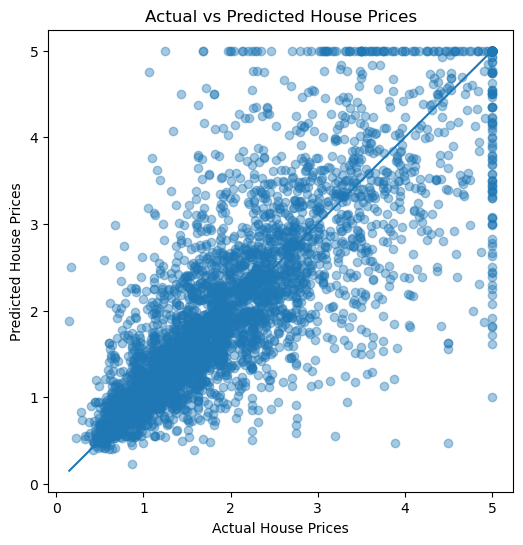

In [9]:

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")

plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

# Conclusion

In [10]:
print("Model Comparison Results")
print(results_df)

best = results_df["R2 Score"].idxmax()

print("\nBest Performing Model:", best)

Model Comparison Results
                       RMSE  R2 Score
Linear Regression  0.745581  0.575788
Ridge Regression   0.745554  0.575819
Decision Tree      0.724234  0.599732

Best Performing Model: Decision Tree
